Need to be re-implemented by ourselves, but should be very similiar or close to RelaxFlow + TRELLIS implementation provided by RelaxFlow.


Notes:
- The original TRELLIS has 2 rectified flow models: sparse structure (ss) generation and slat generation (detailed geometry + appearance)
- TRELLIS.2 has 3 rectified flow models with 4 sampling scheme: ss, geometry slat (w/ a cascade option), and texture/material slat

- By default, `do_feat_blur` and `do_feat_noise` are disabled (`False`) apparently for something unrelated? "V-feature perturbation (ablation)" per their comment in the code ([code ref](https://vscode.dev/github/viridityzhu/RelaxFlow/blob/main/sam3d_objects/pipeline/relaxflow_config.py#L85)). This means we can ignore all code execution paths from that (and we will remove it just for our TRELLIS2 + RelaxFlow implementation)

- By now, the `class RELAXFLOWAttnBlurContext` should be finalized with all the debugs and unnecessary code paths commented out and followed TRELLIS2's different convention of computing rotary embedding in MHA. Focusing on the main custom pipeline class now.

Notes on building `class Trellis2ImageTo3DPipelineRelaxFlow`:
1. All raw image and prior images will get preprocessed to `super().preprocess_image` and `super().get_cond` (DINOv2 image tokenization)... and if there are multiple, it will be combined via `self._pool_prior_tokens()` into one unified prior tokens [same with the SAM3D version]
2. For the sake of simpliciation and speed of implementation, we will assume stage2 (and presumably stage3 for TRELLIS2) all have the same hyperparameters as stage1
3. `_build_alpha_schedule()` seems to be model agnostic (SAM3D and TRELLIS1 has functionally similiar code)
4. most `_(infer/blend)_velocity`, `_build_alpha_schedule`, and `_sample_relaxflow_flow` seems to be model agnostic apart from keyword name changes which is part of the infer params.
5. the only thing that largely needs attention is redoing `sample_sparse_structure_relaxflow`, `sample_slat_relaxflow` with `sample_sparse_structure_relaxflow`, `sample_shape_slat_relaxflow`, `sample_tex_slat_relaxflow`.
6. only `blend`, `prior_only`, `obs_only` (no thens, before it was 3^2 possibilities which we pick 7; now, there's 3^3 possibilities ==> nope)

per 6., we can only do flow ODE on relaxflow itself instead of individual branches

Extra notes:
- update sampler params from "cfg_*" to "guidance_*" once we start running the code


Some extra thinking needs to be involved:

3 branches:
- `obs_only` mesh: basically only pass in observation images (no relaxflow ODE)
- `prior_only` mesh: basically only pass in prior images (no relaxflow ODE)
- `blend` mesh: `blend` ss | `obs` image, `prior` images -> `blend` shape | `blend` coords, `obs` image, `prior` images -> `blend` tex | `blend` slat, `obs` image, `prior` images
`concat_cond` is like the reciprocol of `blend` SLAT (which is a single one), not for each `obs` image, `prior` images (scared me for a second as that suggests impossibility)

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path("~/Documents/vggt2/digitizing_reality/TRELLIS.2").expanduser()))

In [2]:
import os
os.environ['OPENCV_IO_ENABLE_OPENEXR'] = '1'
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # Can save GPU memory
import cv2
import imageio
from PIL import Image
import torch
# from trellis2.pipelines import Trellis2ImageTo3DPipeline
from trellis2.pipelines.relaxflow_pipeline import Trellis2ImageTo3DPipelineRelaxFlow
from trellis2.utils import render_utils
from trellis2.renderers import EnvMap
import o_voxel

# !pip install matplotlib
from matplotlib import pyplot as plt

/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[SPARSE] Conv backend: flex_gemm; Attention backend: flash_attn
[ATTENTION] Using backend: flash_attn


In [3]:
# 1. Setup Environment Map
envmap = EnvMap(torch.tensor(
    cv2.cvtColor(cv2.imread('./TRELLIS.2/assets/hdri/studio.exr', cv2.IMREAD_UNCHANGED), cv2.COLOR_BGR2RGB),
    dtype=torch.float32, device='cuda'
))

# 2. Load Pipeline
pipeline = Trellis2ImageTo3DPipelineRelaxFlow.from_pretrained("microsoft/TRELLIS.2-4B")
pipeline.cuda()

/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [5]:
# from trellis2.pipelines import Trellis2ImageTo3DPipeline
# pipeline = Trellis2ImageTo3DPipeline.from_pretrained("microsoft/TRELLIS.2-4B")
# pipeline.cuda()

slides_img = Image.open("./slides/IMG_9738.jpg").convert("RGB")
slides_prior = Image.open("./slides/IMG_9740.jpg").convert("RGB")

output = pipeline.run_relaxflow(
    slides_img, 
    prior_images=[slides_prior],
    prior_blur_sigma=0.5,
)

mesh = output["relaxflow"]["mesh"][0]
mesh.simplify(16777216)

frames = render_utils.render_video(mesh, envmap=envmap, num_frames=10)

# save each frame
out_dir = Path(f"./slides/amodal_recon_text_guided_sim")
out_dir.mkdir(parents=True, exist_ok=True)

for i, frame in enumerate(frames["shaded"]):
    imageio.imwrite(out_dir / f"view_{i:02d}.png", frame)

INFO:trellis2.pipelines.relaxflow_pipeline:Stage 1: RelaxFlow sparse structure sampling
Sampling: 100%|██████████| 12/12 [00:16<00:00,  1.36s/it]
INFO:trellis2.pipelines.relaxflow_pipeline:Stage 2: RelaxFlow Shape SLAT sampling
INFO:trellis2.pipelines.relaxflow_pipeline:1660 2091 2611
Sampling: 100%|██████████| 12/12 [00:22<00:00,  1.86s/it]
INFO:trellis2.pipelines.relaxflow_pipeline:Stage 3: RelaxFlow Tex SLAT sampling
Sampling: 100%|██████████| 12/12 [00:12<00:00,  1.06s/it]
INFO:trellis2.pipelines.relaxflow_pipeline:Decoding SLAT
Rendering:   0%|          | 0/10 [00:00<?, ?it/s]/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/utils3d/torch/nerf.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior h

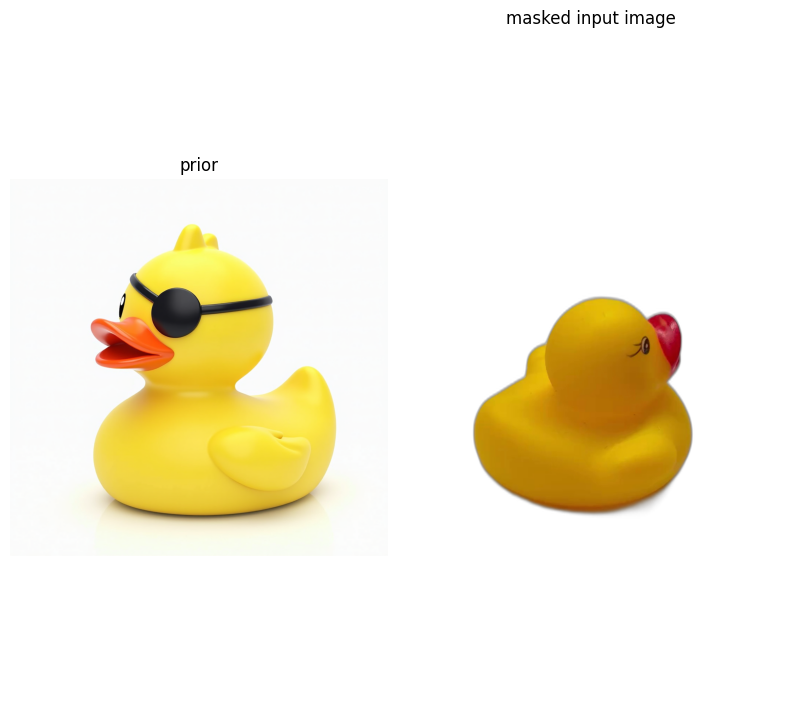

In [4]:
# data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel

# difficult case
# image = Image.open("./data/bike_three_wheels/input.png")
# mask = Image.open("./data/bike_three_wheels/mask.png")
# prior1 = Image.open("./data/bike_three_wheels/prior.jpg")

# image = Image.open("./data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel/image.png")
# mask = Image.open("./data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel/mask.png")
# prior1 = Image.open("./data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel/prior.png")
# masked_image = Image.composite(image, Image.new('RGBA', image.size, (0,0,0,0)), mask)

# # prior1 = Image.open("./eval_data/duck/A yellow rubber duck with jetpack, white background, 3D render.png")
# masked_image = Image.open("./eval_data/duck/gt_obs_segmented/frame_000000.png")

# masked_image = Image.open("./eval_data/chair/gt_obs_segmented/frame_000000.png")



prior1A = Image.open("eval_data/DUCK/pred0/A yellow rubber duck with a pirate eye patch on its left, white background, centered, 3D render.png")
prior1B = Image.open("eval_data/DUCK/pred1/A yellow rubber duck with left eye blue right eye white, white background, centered, 3D render.png")
prior1C = Image.open("eval_data/DUCK/pred2/A yellow rubber duck with the left eye replaced by a googlie eye, white background, centered, 3D render.png")
prior2A = Image.open("eval_data/FLIP_CALENDAR_RED/pred0/Red flip paper calendar with many binder rings showing month of March, white background, centered, 3D render.png")
prior2B = Image.open("eval_data/FLIP_CALENDAR_RED/pred1/Red flip paper calendar with many binder rings showing month of April (on a yellow paper on top of the red flip calendar), white background, centered, 3D render.png")
prior2C = Image.open("eval_data/FLIP_CALENDAR_RED/pred2/Red flip paper calendar with many binder rings showing with two large flip placards representing the month and the day, white background, centered, 3D render.png")

masked_image1 = Image.open("./eval_data/DUCK/gt_obs_segmented/frame_000000.png")
masked_image2 = Image.open("./eval_data/FLIP_CALENDAR_RED/gt_obs_segmented/frame_000001.png")

fig, axes = plt.subplots(1, 2, figsize=(8, 8))

axes[0].axis("off")
axes[0].imshow(prior1A)
axes[0].set_title("prior")

axes[1].axis("off")
axes[1].imshow(masked_image1)
axes[1].set_title("masked input image")

# axes[1, 0].axis("off")
# axes[1, 0].imshow(prior1)
# axes[1, 0].set_title("prior1")

# axes[1, 1].axis("off")
# axes[1, 1].imshow(masked_image)
# axes[1, 1].set_title("masked_image")

plt.tight_layout()
plt.show()


In [5]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

NameError: name 'gc' is not defined

In [ ]:
import gc

for masked_img, prior, path in [
    # (masked_image1, prior1A, "DUCK/pred0"),
    # (masked_image1, prior1B, "DUCK/pred1"),
    # (masked_image1, prior1C, "DUCK/pred2"),
    # (masked_image2, prior2A, "FLIP_CALENDAR_RED/pred0"),
    # (masked_image2, prior2B, "FLIP_CALENDAR_RED/pred1"),
    # (masked_image2, prior2C, "FLIP_CALENDAR_RED/pred2"),
]:
    output = pipeline.run_relaxflow(
        masked_img, 
        prior_images=[prior],
        prior_blur_sigma=1.0,
    )

    mesh = output["relaxflow"]["mesh"][0]
    mesh.simplify(16777216)

    frames = render_utils.render_video(mesh, envmap=envmap, num_frames=10)

    # save each frame
    out_dir = Path(f"./eval_data/{path}/TRELLIS.2")
    out_dir.mkdir(parents=True, exist_ok=True)

    for i, frame in enumerate(frames["shaded"]):
        imageio.imwrite(out_dir / f"view_{i:02d}.png", frame)

    print(f"Saved {len(frames['shaded'])} views to {out_dir}")

    del frames, mesh, output
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

INFO:trellis2.pipelines.relaxflow_pipeline:Stage 1: RelaxFlow sparse structure sampling
Sampling: 100%|██████████| 12/12 [00:16<00:00,  1.39s/it]
INFO:trellis2.pipelines.relaxflow_pipeline:Stage 2: RelaxFlow Shape SLAT sampling
INFO:trellis2.pipelines.relaxflow_pipeline:5602 4245 5093
Sampling: 100%|██████████| 12/12 [00:59<00:00,  4.94s/it]
INFO:trellis2.pipelines.relaxflow_pipeline:Stage 3: RelaxFlow Tex SLAT sampling
Sampling: 100%|██████████| 12/12 [00:34<00:00,  2.84s/it]
INFO:trellis2.pipelines.relaxflow_pipeline:Decoding SLAT


OutOfMemoryError: CUDA out of memory. Tried to allocate 10.02 GiB. GPU 0 has a total capacity of 22.07 GiB of which 8.33 GiB is free. Including non-PyTorch memory, this process has 13.72 GiB memory in use. Of the allocated memory 13.09 GiB is allocated by PyTorch, and 279.39 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [5]:
output = pipeline.run_relaxflow(
    masked_image1, 
    # image,
    prior_images=[prior1A],
    prior_blur_sigma=1.0,
)

INFO:trellis2.pipelines.relaxflow_pipeline:Stage 1: RelaxFlow sparse structure sampling
Sampling: 100%|██████████| 12/12 [00:16<00:00,  1.40s/it]
INFO:trellis2.pipelines.relaxflow_pipeline:Stage 2: RelaxFlow Shape SLAT sampling
INFO:trellis2.pipelines.relaxflow_pipeline:5001 5117 4937
Sampling: 100%|██████████| 12/12 [01:06<00:00,  5.53s/it]
INFO:trellis2.pipelines.relaxflow_pipeline:Stage 3: RelaxFlow Tex SLAT sampling
Sampling: 100%|██████████| 12/12 [00:37<00:00,  3.16s/it]
INFO:trellis2.pipelines.relaxflow_pipeline:Decoding SLAT


In [9]:
# ...existing code...
# pick ONE mesh (same mesh, multiple camera views)
mesh = output["relaxflow"]["mesh"][0]   # or output["obs_only"]["mesh"][0]
mesh.simplify(16777216)

# render 10 views around the same mesh
frames = render_utils.render_video(mesh, envmap=envmap, num_frames=10)
# frames = render_utils.make_pbr_vis_frames(frames)

# print(frames.keys())

# save each frame
out_dir = Path("./eval_data/DUCK/pred0/TRELLIS.2")
out_dir.mkdir(parents=True, exist_ok=True)

for i, frame in enumerate(frames["shaded"]):
    imageio.imwrite(out_dir / f"view_{i:02d}.png", frame)

print(f"Saved {len(frames['shaded'])} views to {out_dir}")

Rendering:   0%|          | 0/10 [00:00<?, ?it/s]

/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/utils3d/torch/nerf.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Rendering: 100%|██████████| 10/10 [00:04<00:00,  2.37it/s]


Saved 10 views to eval_data/DUCK/pred0/TRELLIS.2


In [10]:
# output = pipeline.run_relaxflow(
#     masked_image, 
#     # image,
#     prior_images=[prior1],
#     # pipeline_type = '1536_cascade',
#     # prior_blur_sigma=1.0,

#     # prior_weight = 2.0,
#     prior_blur_sigma=1.0,
#     # stage1_inference_steps=120,

#     # prior_weight = 1.2,
#     # prior_blur_sigma=1.0,
#     # stage1_inference_steps=40,
#     # flow_blend_name="residual_pull",
# )

mesh_relaxflow = output["relaxflow"]["mesh"][0]
mesh_obs = output["obs_only"]["mesh"][0]
mesh_prior = output["prior_only"]["mesh"][0]
# nvdiffrast limit
mesh_relaxflow.simplify(16777216)
mesh_obs.simplify(16777216)
mesh_prior.simplify(16777216)

# 4. Render Video
video = render_utils.make_pbr_vis_frames(render_utils.render_video(mesh_relaxflow, envmap=envmap, num_frames=60))
imageio.mimsave("./data/eval/TRELLIS2_RelaxFlow_Combined.gif", video, fps=15, loop=0)

video = render_utils.make_pbr_vis_frames(render_utils.render_video(mesh_obs, envmap=envmap, num_frames=60))
imageio.mimsave("./data/eval/TRELLIS2_RelaxFlow_Observation.gif", video, fps=15, loop=0)

video = render_utils.make_pbr_vis_frames(render_utils.render_video(mesh_prior, envmap=envmap, num_frames=60))
imageio.mimsave("./data/eval/TRELLIS2_RelaxFlow_Prior.gif", video, fps=15, loop=0)


# # 5. Export to GLB
# glb = o_voxel.postprocess.to_glb(
#     vertices            =   mesh.vertices,
#     faces               =   mesh.faces,
#     attr_volume         =   mesh.attrs,
#     coords              =   mesh.coords,
#     attr_layout         =   mesh.layout,
#     voxel_size          =   mesh.voxel_size,
#     aabb                =   [[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
#     decimation_target   =   1000000,
#     texture_size        =   4096,
#     remesh              =   True,
#     remesh_band         =   1,
#     remesh_project      =   0,
#     verbose             =   True
# )
# glb.export("sample.glb", extension_webp=True)

Rendering: 100%|██████████| 60/60 [00:25<00:00,  2.35it/s]


In terms of the interface, the only changes are the parameter naming change from "`cfg_*`" to "`guidance_*`" and implicating `neg_cond` in the guidance interval mixin (into `**kwarg`) => so no functional changes in the code expected from the integration.

```sh
      /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers
diff -ru /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/classifier_free_guidance_mixin.py /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/classifier_free_guidance_mixin.py
--- /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/classifier_free_guidance_mixin.py   2026-03-31 18:46:09.586168018 -0700
+++ /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/classifier_free_guidance_mixin.py2026-04-03 21:56:32.265903798 -0700
@@ -6,7 +6,24 @@
     A mixin class for samplers that apply classifier-free guidance.
     """
 
-    def _inference_model(self, model, x_t, t, cond, neg_cond, cfg_strength, **kwargs):
-        pred = super()._inference_model(model, x_t, t, cond, **kwargs)
-        neg_pred = super()._inference_model(model, x_t, t, neg_cond, **kwargs)
-        return (1 + cfg_strength) * pred - cfg_strength * neg_pred
+    def _inference_model(self, model, x_t, t, cond, neg_cond, guidance_strength, guidance_rescale=0.0, **kwargs):
+        if guidance_strength == 1:
+            return super()._inference_model(model, x_t, t, cond, **kwargs)
+        elif guidance_strength == 0:
+            return super()._inference_model(model, x_t, t, neg_cond, **kwargs)
+        else:
+            pred_pos = super()._inference_model(model, x_t, t, cond, **kwargs)
+            pred_neg = super()._inference_model(model, x_t, t, neg_cond, **kwargs)
+            pred = guidance_strength * pred_pos + (1 - guidance_strength) * pred_neg
+            
+            # CFG rescale
+            if guidance_rescale > 0:
+                x_0_pos = self._pred_to_xstart(x_t, t, pred_pos)
+                x_0_cfg = self._pred_to_xstart(x_t, t, pred)
+                std_pos = x_0_pos.std(dim=list(range(1, x_0_pos.ndim)), keepdim=True)
+                std_cfg = x_0_cfg.std(dim=list(range(1, x_0_cfg.ndim)), keepdim=True)
+                x_0_rescaled = x_0_cfg * (std_pos / std_cfg)
+                x_0 = guidance_rescale * x_0_rescaled + (1 - guidance_rescale) * x_0_cfg
+                pred = self._xstart_to_pred(x_t, t, x_0)
+                
+            return pred
diff -ru /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/flow_euler.py /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/flow_euler.py
--- /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/flow_euler.py       2026-03-31 18:46:09.586168018 -0700
+++ /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/flow_euler.py    2026-04-03 21:56:32.265903798 -0700
@@ -34,11 +34,15 @@
         eps = (1 - t) * v + x_t
         x_0 = (1 - self.sigma_min) * x_t - (self.sigma_min + (1 - self.sigma_min) * t) * v
         return x_0, eps
+    
+    def _pred_to_xstart(self, x_t, t, pred):
+        return (1 - self.sigma_min) * x_t - (self.sigma_min + (1 - self.sigma_min) * t) * pred
+
+    def _xstart_to_pred(self, x_t, t, x_0):
+        return ((1 - self.sigma_min) * x_t - x_0) / (self.sigma_min + (1 - self.sigma_min) * t)
 
     def _inference_model(self, model, x_t, t, cond=None, **kwargs):
         t = torch.tensor([1000 * t] * x_t.shape[0], device=x_t.device, dtype=torch.float32)
-        if cond is not None and cond.shape[0] == 1 and x_t.shape[0] > 1:
-            cond = cond.repeat(x_t.shape[0], *([1] * (len(cond.shape) - 1)))
         return model(x_t, t, cond, **kwargs)
 
     def _get_model_prediction(self, model, x_t, t, cond=None, **kwargs):
@@ -85,6 +89,7 @@
         steps: int = 50,
         rescale_t: float = 1.0,
         verbose: bool = True,
+        tqdm_desc: str = "Sampling",
         **kwargs
     ):
         """
@@ -97,6 +102,7 @@
             steps: The number of steps to sample.
             rescale_t: The rescale factor for t.
             verbose: If True, show a progress bar.
+            tqdm_desc: A customized tqdm desc.
             **kwargs: Additional arguments for model_inference.
 
         Returns:
@@ -108,9 +114,10 @@
         sample = noise
         t_seq = np.linspace(1, 0, steps + 1)
         t_seq = rescale_t * t_seq / (1 + (rescale_t - 1) * t_seq)
+        t_seq = t_seq.tolist()
         t_pairs = list((t_seq[i], t_seq[i + 1]) for i in range(steps))
         ret = edict({"samples": None, "pred_x_t": [], "pred_x_0": []})
-        for t, t_prev in tqdm(t_pairs, desc="Sampling", disable=not verbose):
+        for t, t_prev in tqdm(t_pairs, desc=tqdm_desc, disable=not verbose):
             out = self.sample_once(model, sample, t, t_prev, cond, **kwargs)
             sample = out.pred_x_prev
             ret.pred_x_t.append(out.pred_x_prev)
@@ -132,7 +139,7 @@
         neg_cond,
         steps: int = 50,
         rescale_t: float = 1.0,
-        cfg_strength: float = 3.0,
+        guidance_strength: float = 3.0,
         verbose: bool = True,
         **kwargs
     ):
@@ -146,7 +153,7 @@
             neg_cond: negative conditional information.
             steps: The number of steps to sample.
             rescale_t: The rescale factor for t.
-            cfg_strength: The strength of classifier-free guidance.
+            guidance_strength: The strength of classifier-free guidance.
             verbose: If True, show a progress bar.
             **kwargs: Additional arguments for model_inference.
 
@@ -156,10 +163,10 @@
             - 'pred_x_t': a list of prediction of x_t.
             - 'pred_x_0': a list of prediction of x_0.
         """
-        return super().sample(model, noise, cond, steps, rescale_t, verbose, neg_cond=neg_cond, cfg_strength=cfg_strength, **kwargs)
+        return super().sample(model, noise, cond, steps, rescale_t, verbose, neg_cond=neg_cond, guidance_strength=guidance_strength, **kwargs)
 
 
-class FlowEulerGuidanceIntervalSampler(GuidanceIntervalSamplerMixin, FlowEulerSampler):
+class FlowEulerGuidanceIntervalSampler(GuidanceIntervalSamplerMixin, ClassifierFreeGuidanceSamplerMixin, FlowEulerSampler):
     """
     Generate samples from a flow-matching model using Euler sampling with classifier-free guidance and interval.
     """
@@ -172,8 +179,8 @@
         neg_cond,
         steps: int = 50,
         rescale_t: float = 1.0,
-        cfg_strength: float = 3.0,
-        cfg_interval: Tuple[float, float] = (0.0, 1.0),
+        guidance_strength: float = 3.0,
+        guidance_interval: Tuple[float, float] = (0.0, 1.0),
         verbose: bool = True,
         **kwargs
     ):
@@ -187,8 +194,8 @@
             neg_cond: negative conditional information.
             steps: The number of steps to sample.
             rescale_t: The rescale factor for t.
-            cfg_strength: The strength of classifier-free guidance.
-            cfg_interval: The interval for classifier-free guidance.
+            guidance_strength: The strength of classifier-free guidance.
+            guidance_interval: The interval for classifier-free guidance.
             verbose: If True, show a progress bar.
             **kwargs: Additional arguments for model_inference.
 
@@ -198,4 +205,4 @@
             - 'pred_x_t': a list of prediction of x_t.
             - 'pred_x_0': a list of prediction of x_0.
         """
-        return super().sample(model, noise, cond, steps, rescale_t, verbose, neg_cond=neg_cond, cfg_strength=cfg_strength, cfg_interval=cfg_interval, **kwargs)
+        return super().sample(model, noise, cond, steps, rescale_t, verbose, neg_cond=neg_cond, guidance_strength=guidance_strength, guidance_interval=guidance_interval, **kwargs)
diff -ru /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/guidance_interval_mixin.py /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/guidance_interval_mixin.py
--- /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/guidance_interval_mixin.py  2026-03-31 18:46:09.586168018 -0700
+++ /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/guidance_interval_mixin.py       2026-04-03 21:56:32.265903798 -0700
@@ -6,10 +6,8 @@
     A mixin class for samplers that apply classifier-free guidance with interval.
     """
 
-    def _inference_model(self, model, x_t, t, cond, neg_cond, cfg_strength, cfg_interval, **kwargs):
-        if cfg_interval[0] <= t <= cfg_interval[1]:
-            pred = super()._inference_model(model, x_t, t, cond, **kwargs)
-            neg_pred = super()._inference_model(model, x_t, t, neg_cond, **kwargs)
-            return (1 + cfg_strength) * pred - cfg_strength * neg_pred
+    def _inference_model(self, model, x_t, t, cond, guidance_strength, guidance_interval, **kwargs):
+        if guidance_interval[0] <= t <= guidance_interval[1]:
+            return super()._inference_model(model, x_t, t, cond, guidance_strength=guidance_strength, **kwargs)
         else:
-            return super()._inference_model(model, x_t, t, cond, **kwargs)
+            return super()._inference_model(model, x_t, t, cond, guidance_strength=1, **kwargs)
diff -ru /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__init__.py /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/__init__.py
--- /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__init__.py 2026-03-31 18:46:09.586141758 -0700
+++ /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/__init__.py      2026-04-03 21:56:32.265878008 -0700
@@ -1,2 +1,6 @@
 from .base import Sampler
-from .flow_euler import FlowEulerSampler, FlowEulerCfgSampler, FlowEulerGuidanceIntervalSampler
\ No newline at end of file
+from .flow_euler import (
+    FlowEulerSampler,
+    FlowEulerCfgSampler,
+    FlowEulerGuidanceIntervalSampler,
+)
\ No newline at end of file
Binary files /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__/base.cpython-310.pyc and /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/__pycache__/base.cpython-310.pyc differ
Only in /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__: base.cpython-311.pyc
Binary files /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__/classifier_free_guidance_mixin.cpython-310.pyc and /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/__pycache__/classifier_free_guidance_mixin.cpython-310.pyc differ
Only in /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__: classifier_free_guidance_mixin.cpython-311.pyc
Binary files /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__/flow_euler.cpython-310.pyc and /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/__pycache__/flow_euler.cpython-310.pyc differ
Only in /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__: flow_euler.cpython-311.pyc
Binary files /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__/guidance_interval_mixin.cpython-310.pyc and /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/__pycache__/guidance_interval_mixin.cpython-310.pyc differ
Only in /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__: guidance_interval_mixin.cpython-311.pyc
Binary files /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__/__init__.cpython-310.pyc and /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS.2/trellis2/pipelines/samplers/__pycache__/__init__.cpython-310.pyc differ
Only in /home/ahc/Documents/vggt2/digitizing_reality/TRELLIS/trellis/pipelines/samplers/__pycache__: __init__.cpython-311.pyc
```